In [ ]:
%pip install langchain langchain-ollama langchain-core

In [ ]:
%pip install langchain-community

In [8]:
# import all libreries
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph.message import add_messages
import operator
from langgraph.checkpoint.memory import MemorySaver

#### Human message: human provide
#### Ai message : AI generation
#### system message : role define prompt

In [9]:
# define state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [10]:
chat_model = ChatOllama(model="llama3.2:1b", temperature=0)
def chatnode(state:ChatState):
    messages = state['messages']
    prompt = ""
    response = chat_model.invoke(messages)
    return {"messages":[response]}


In [11]:
# create a graph
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chatnode",chatnode)

graph.add_edge(START,'chatnode')
graph.add_edge('chatnode',END)

chatbot = graph.compile(checkpointer=checkpointer)

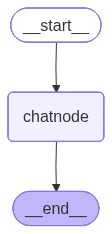

In [12]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [13]:
initial_state = {
    'messages':[HumanMessage(content = "what is the capital of India?")]
}

response = chatbot.invoke(initial_state)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [14]:
response['messages'][-1].content

NameError: name 'response' is not defined

In [15]:
# running in continuous loop
thread_id = "1"
while True:
    user_query = input('type here : ')
    print(user_query)
    if user_query.strip().lower() in ['exit','quit','bye','q']:
        break
    initial_state = {
        "messages":[HumanMessage(content=f"{user_query}")]
    }
    config = {"configurable":{"thread_id":thread_id}}
    response = chatbot.invoke(initial_state,config = config)

    print(response['messages'][-1].content)

hi
How can I help you today?
My name is Moumita
Hello Moumita, it's nice to meet you. Is there something on your mind that you'd like to talk about or ask for help with?
what is my name?
Your name is Moumita. I should have remembered that earlier. How can I assist you today, Moumita?
add 100 and 12
To add 100 and 12, I'll perform the calculation:

100 + 12 = 112
wow, now multiply with 2 
I'll multiply 112 by 2:

112 × 2 = 224
q
